In [1]:
import os
os.chdir(r"D:\teleco-churn-project\teleco-churn")
from pathlib import Path
from src.train import train_model,save_model,load_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier,BaggingClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.evaluate import eval_model,cross_validation

In [2]:
data=pd.read_csv("data/processed/processed_data.csv")

In [3]:
data.head()

,num__Account_Length,num__Vmail_Message,num__CustServ_Calls,num__Area_Code,num__Total_cals,num__total_charges,cat__Intl_Plan_no,cat__Intl_Plan_yes,cat__Vmail_Plan_no,cat__Vmail_Plan_yes,...,cat__State_TN,cat__State_TX,cat__State_UT,cat__State_VA,cat__State_VT,cat__State_WA,cat__State_WI,cat__State_WV,cat__State_WY,churn
0,0.676489,1.234883,-0.427932,-0.523603,-0.062048,1.534209,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.149065,1.307948,-0.427932,-0.523603,0.779923,-0.019975,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.902529,-0.591760,-1.188218,-0.523603,0.808957,0.270482,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.428590,-0.591760,0.332354,-0.688834,-1.455655,0.699978,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-0.654629,-0.591760,1.092641,-0.523603,1.563827,-0.700883,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
x=data.drop(['churn'],axis=1)
y=data['churn']

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42 ,shuffle=True)

In [6]:
len(x_train),len(y_train),len(x_test),len(y_test)

(2666, 2666, 667, 667)

In [7]:
logistic_model=train_model(LogisticRegression(class_weight='balanced'),x_train,y_train)


======== Model = Logistic Regression Model ========
Accuracy: 0.5652
F1 Score: 0.3830
Precision: 0.2439
Recall: 0.8911
ROC-AUC: 0.8263


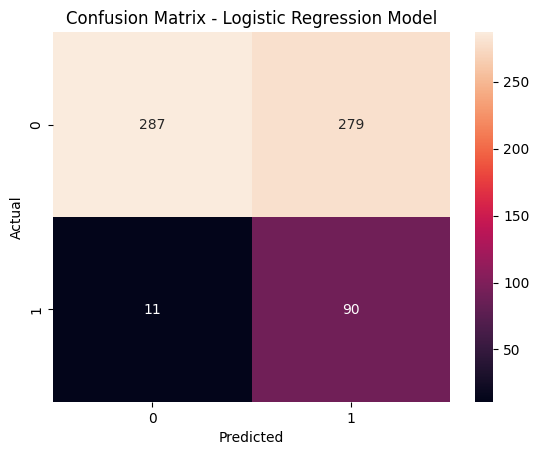


====== Classification Report ======
              precision    recall  f1-score   support

           0       0.96      0.51      0.66       566
           1       0.24      0.89      0.38       101

    accuracy                           0.57       667
   macro avg       0.60      0.70      0.52       667
weighted avg       0.85      0.57      0.62       667


====== Precision-Recall Curve ======


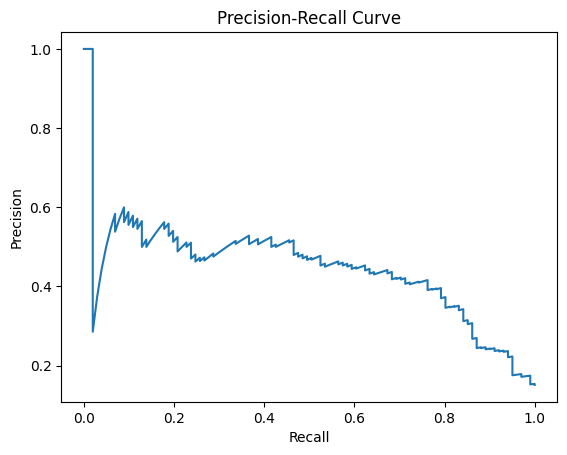

In [8]:
eval_model(logistic_model,x_test,y_test,model_name='Logistic Regression Model')

In [9]:
adabost_model=train_model(AdaBoostClassifier(),x_train,y_train)


======== Model = AdaBost Classifier Model ========
Accuracy: 0.2894
F1 Score: 0.2904
Precision: 0.1711
Recall: 0.9604
ROC-AUC: 0.8929


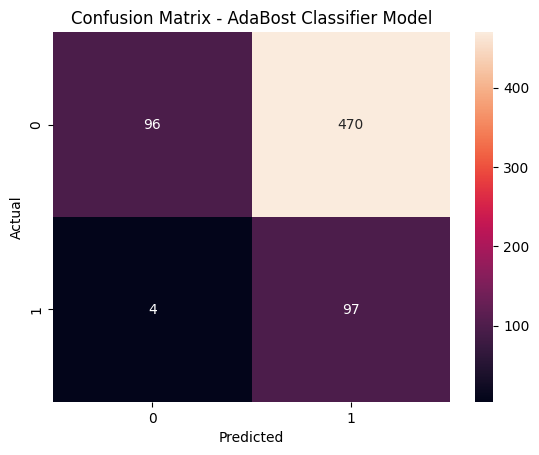


====== Classification Report ======
              precision    recall  f1-score   support

           0       0.96      0.17      0.29       566
           1       0.17      0.96      0.29       101

    accuracy                           0.29       667
   macro avg       0.57      0.57      0.29       667
weighted avg       0.84      0.29      0.29       667


====== Precision-Recall Curve ======


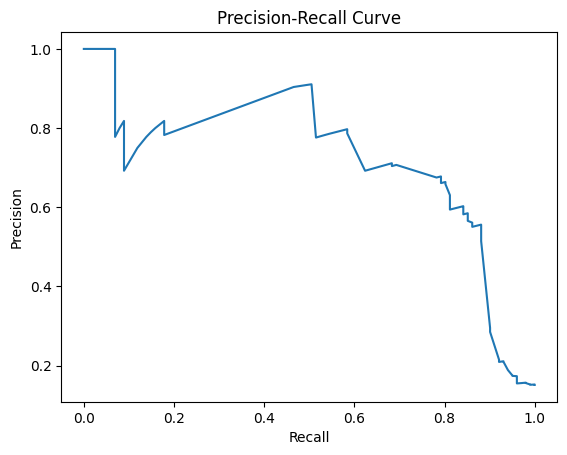

In [10]:
eval_model(adabost_model,x_test,y_test,model_name='AdaBost Classifier Model')

### Optimal Values 
    Recall (class 1): 0.70 – 0.90. 
    Precision: 0.30 – 0.60. 
    ROC-AUC: > 0.80. 
    F1: depends, but usually > 0.40 is decent. 

In [11]:
bagging_classifier=train_model(BaggingClassifier(),x_train,y_train)


======== Model = bagging Classifier Model ========
Accuracy: 0.9070
F1 Score: 0.7207
Precision: 0.6612
Recall: 0.7921
ROC-AUC: 0.9014


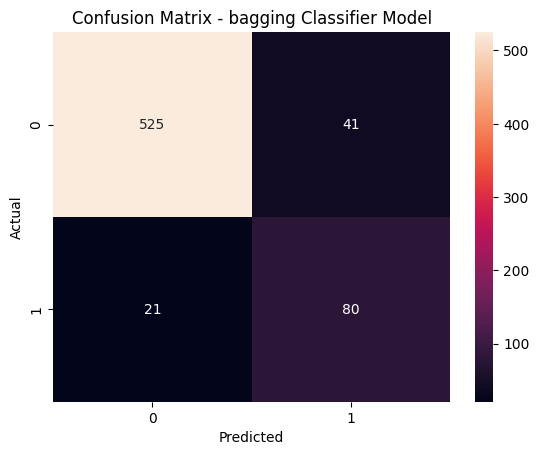


====== Classification Report ======
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       566
           1       0.66      0.79      0.72       101

    accuracy                           0.91       667
   macro avg       0.81      0.86      0.83       667
weighted avg       0.92      0.91      0.91       667


====== Precision-Recall Curve ======


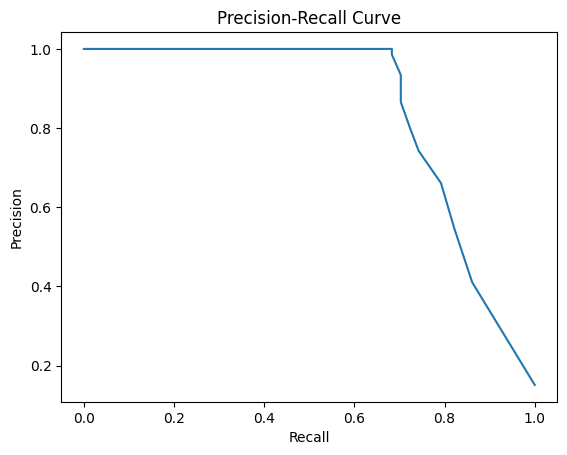

In [12]:
eval_model(bagging_classifier,x_test,y_test,model_name='bagging Classifier Model')

### AdaBost Classifier is our Best model so  far in our expermentataion 

In [13]:
Gradient_Boosting_Classifier=train_model(GradientBoostingClassifier(),x_train,y_train)


======== Model = Gradient_Boosting_Classifier Model ========
Accuracy: 0.9160
F1 Score: 0.7282
Precision: 0.7143
Recall: 0.7426
ROC-AUC: 0.9327


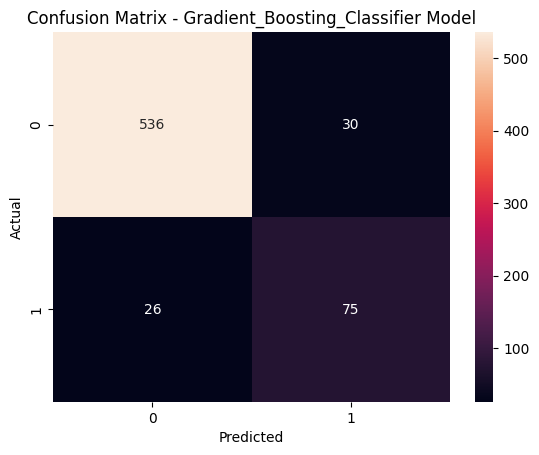


====== Classification Report ======
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       566
           1       0.71      0.74      0.73       101

    accuracy                           0.92       667
   macro avg       0.83      0.84      0.84       667
weighted avg       0.92      0.92      0.92       667


====== Precision-Recall Curve ======


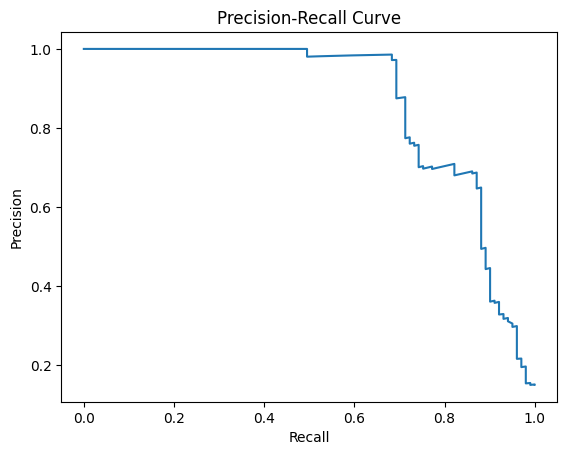

In [14]:
eval_model(Gradient_Boosting_Classifier,x_test,y_test,model_name='Gradient_Boosting_Classifier Model')

In [15]:
DecisionTree_Classifier=train_model(DecisionTreeClassifier(class_weight='balanced'),x_train,y_train)


======== Model = DecisionTree_Classifier Model ========
Accuracy: 0.9265
F1 Score: 0.7610
Precision: 0.7500
Recall: 0.7723
ROC-AUC: 0.8632


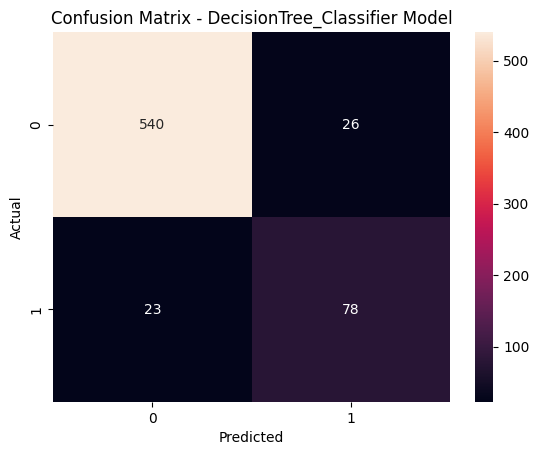


====== Classification Report ======
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       566
           1       0.75      0.77      0.76       101

    accuracy                           0.93       667
   macro avg       0.85      0.86      0.86       667
weighted avg       0.93      0.93      0.93       667


====== Precision-Recall Curve ======


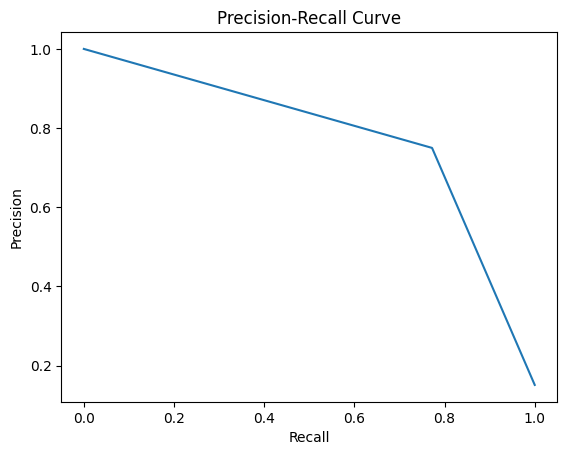

In [16]:
eval_model(DecisionTree_Classifier,x_test,y_test,model_name='DecisionTree_Classifier Model')

In [17]:
logistic_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:


save_model(
    logistic_model,
    "logistic_model",
    r"D:\teleco-churn-project\teleco-churn\models"
)

Model Saved to D:\teleco-churn-project\teleco-churn\models\logistic_model.pkl


In [28]:
save_model(
    adabost_model,
    "AdaBost_model",
    r"D:\teleco-churn-project\teleco-churn\models"
)

Model Saved to D:\teleco-churn-project\teleco-churn\models\AdaBost_model.pkl


In [29]:
save_model(
    bagging_classifier,
    "bagging_classifierg_model",
    r"D:\teleco-churn-project\teleco-churn\models"
)

Model Saved to D:\teleco-churn-project\teleco-churn\models\bagging_classifierg_model.pkl


In [30]:
save_model(
    Gradient_Boosting_Classifier,
    "Gradient_Boosting_Classifiermodel",
    r"D:\teleco-churn-project\teleco-churn\models"
)

Model Saved to D:\teleco-churn-project\teleco-churn\models\Gradient_Boosting_Classifiermodel.pkl


In [26]:
save_model(
    DecisionTree_Classifier,
    "DecisionTree_Classifier_model",
    r"D:\teleco-churn-project\teleco-churn\models"
)

Model Saved to D:\teleco-churn-project\teleco-churn\models\DecisionTree_Classifier_model.pkl
